### To check if the model initially designed for Dakar can be used for other locations

In [ ]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                                     # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

2024-11-26 16:39:12.490673: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-26 16:39:12.941358: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-26 16:39:14.753912: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-26 16:39:17.302155: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Importing dataset

In [2]:
data = pd.read_csv("train-data-Dakar.csv", index_col=False)
test_data = pd.read_csv("test-data-Dakar.csv", index_col=False)

### Check if the data have outliers

In [3]:
data

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_Dakar_t1,Cb_Dakar_t3,Cb_Dakar_t6
0,2004,6,1,17,45,12.08,-8.22,10.06,-8.13,14.716677,...,0.0,0.0,325.14,352.41,520.00,520.00,520.00,0.0,0.0,0.0
1,2004,6,1,18,0,12.13,-8.18,10.02,-8.31,14.716677,...,0.0,0.0,326.53,347.12,520.00,520.00,520.00,0.0,0.0,0.0
2,2004,6,1,18,15,12.17,-8.18,10.02,-8.45,14.716677,...,0.0,0.0,326.27,343.59,520.00,520.00,520.00,0.0,0.0,0.0
3,2004,6,1,18,30,12.00,-8.94,12.13,-8.27,14.716677,...,0.0,0.0,301.39,323.64,520.00,520.00,520.00,0.0,0.0,0.0
4,2004,6,1,18,45,12.04,-8.85,10.60,-8.18,14.716677,...,0.0,0.0,304.60,343.29,520.00,520.00,520.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103872,2019,9,30,5,0,12.62,-16.04,12.08,-17.03,13.340000,...,14650.0,0.0,72.47,83.35,91.27,109.44,520.00,0.0,0.0,0.0
103873,2019,9,30,5,15,13.39,-15.72,12.76,-16.04,12.130000,...,11800.0,11800.0,71.06,79.61,89.20,105.99,123.49,0.0,0.0,0.0
103874,2019,9,30,5,30,12.00,-16.49,12.22,-17.07,14.716677,...,0.0,0.0,86.21,97.27,520.00,520.00,520.00,0.0,0.0,0.0
103875,2019,9,30,6,0,11.41,-17.07,12.31,-16.98,14.716677,...,0.0,0.0,83.60,115.07,520.00,520.00,520.00,0.0,0.0,0.0


In [4]:
variable = "lon"
for i in range(5):
    print(np.min(data[f"{variable}{i+1}"]), np.max(data[f"{variable}{i+1}"]))

-17.97 -8.04
-17.97 -8.04
-17.97 -2.4676860000000005
-17.97 -2.4676860000000005
-17.97 -2.4676860000000005


### Exploratory Data Analysis

In [5]:
def select(df):
    selection_index_lat = df["lat5"] < 30
    selection_index_lon = df["lon5"] < 30
    selection_index = selection_index_lat * selection_index_lon
    return selection_index

index_train = select(data)
index_test = select(test_data)

data = data[index_train]
test_data = test_data[index_test]

In [6]:
data = data.dropna()
test_data = test_data.dropna()

#### Choosing field to include in the data

In [7]:
lead_time = 3

In [8]:
# Presence or absence of storms in Dakar at time t+1
target_index = f"Cb_Dakar_t{lead_time}"

# Input at time t
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')
data = data[field]
test_data = test_data[field]

### Transforming latitude and longitude to relative latitude and relative longitude

In [7]:
Dakar_lon = -17.467686
Dakar_lat = 14.716677

In [8]:
Dakar_y, Dakar_x = nflics.X0(Dakar_lat, Dakar_lon)
Out_y, Out_x = nflics.X0(Dakar_lat, Dakar_lon+15)
round(np.sqrt((Dakar_y - Out_y)**2+ (Dakar_x - Out_x)**2))

520

### Correcting padding

In [702]:
"""for i in range(5):
    data.loc[data[f'size{i+1}'] == 0, [f'lat{i+1}', f'lon{i+1}', f'ds{i+1}']] = [Dakar_lat, Dakar_lon + 15, 520]
    test_data.loc[test_data[f'size{i+1}'] == 0, [f'lat{i+1}', f'lon{i+1}', f'ds{i+1}']] = [Dakar_lat, Dakar_lon + 15, 520]"""

"for i in range(5):\n    data.loc[data[f'size{i+1}'] == 0, [f'lat{i+1}', f'lon{i+1}', f'ds{i+1}']] = [Dakar_lat, Dakar_lon + 15, 520]\n    test_data.loc[test_data[f'size{i+1}'] == 0, [f'lat{i+1}', f'lon{i+1}', f'ds{i+1}']] = [Dakar_lat, Dakar_lon + 15, 520]"

### Transforming to relative latitude and longitudes

In [9]:
for i in range(5):
    data[f"lat{i+1}"] = data[f"lat{i+1}"] - Dakar_lat
    data[f"lon{i+1}"] = data[f"lon{i+1}"] - Dakar_lon
    test_data[f"lat{i+1}"] = test_data[f"lat{i+1}"] - Dakar_lat
    test_data[f"lon{i+1}"] = test_data[f"lon{i+1}"] - Dakar_lon

In [12]:
data["lon5"]

0         15.000000
1         15.000000
2         15.000000
3         15.000000
4         15.000000
            ...    
103872    15.000000
103873     0.977686
103874    15.000000
103875    15.000000
103876    15.000000
Name: lon5, Length: 103877, dtype: float64

### Exploratory data analysis

In [17]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [18]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [19]:
to_scale = wavelet_power + storm_size + distance

In [20]:
transform = True
if transform:
    data = log_transform(data, to_scale.split(',')[:-1])    
    data = sqrt_transform(data, t0.split(',')[:-1])
    test_data = log_transform(test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(test_data, t0.split(',')[:-1])

### Splitting the data  into training and testing before oversampling the training set

In [21]:
train, validation = train_test_split(data, test_size=0.2, random_state=12)

In [22]:
neg, pos = train[target_index].value_counts()
total = neg + pos
print(f"Negative: {neg} and Positive: {pos}. That is {pos/total:.2f} of the total.")

Negative: 76886 and Positive: 6215. That is 0.07 of the total.


In [23]:
x_train = train.drop([target_index], axis=1).to_numpy()
y_train = train[target_index]

x_val = validation.drop([target_index], axis=1).to_numpy()
y_val = validation[target_index]

x_test = test_data.drop([target_index], axis=1).to_numpy()
y_test = test_data[target_index]

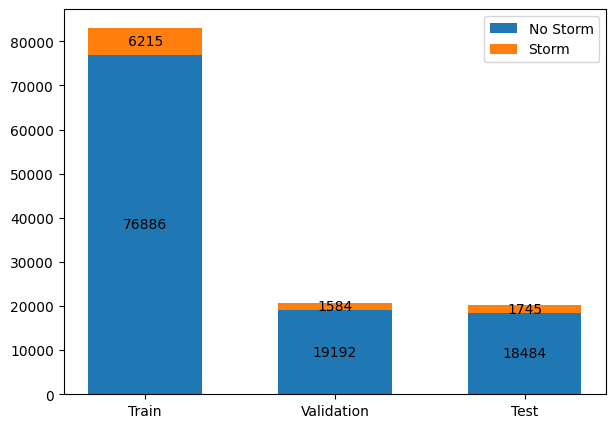

In [24]:
type = ('Train', 'Validation', 'Test')

storm_counts = {
    'No Storm': np.array([y_train.value_counts()[0], y_val.value_counts()[0], y_test.value_counts()[0]]),
    'Storm': np.array([y_train.value_counts()[1], y_val.value_counts()[1] , y_test.value_counts()[1]]),
}
width = 0.6  # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(7,5))
bottom = np.zeros(3)

for mode, count in storm_counts.items():
    p = ax.bar(type, count, width, label=mode, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center')

ax.legend()

plt.show()

### Normalising the features

In [25]:
# normalise data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [713]:
#dump(scaler, f'Global-t{lead_time}.bin', compress=True)

['Global-t3.bin']

### Creating the model

In [26]:
initial_bias = np.log(pos/neg)
output_bias = tf.keras.initializers.Constant(value=initial_bias)

model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(30,)),
  tf.keras.layers.Dense(16, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dropout(0.2),    
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)
])

l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:
  layer.kernel_regularizer = l1_reg

cl_thresholds = 0.25

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=METRICS)

In [27]:
model.summary()data

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673 (2.63 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [28]:
EPOCHS = 500
BATCH_SIZE = 1024

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)


# train the model
model_history = model.fit(x_train, 
                          y_train, 
                          epochs=EPOCHS, 
                          callbacks = [early_stopping],
                          batch_size = BATCH_SIZE,         
                          validation_data=(x_val, y_val),
                        )

Epoch 1/500
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - auc: 0.6326 - bs: 0.0688 - f1_score: 0.0012 - loss: 0.2634 - prc: 0.1127 - precision: 0.0633 - recall: 6.2921e-04 - tn: 39770.2305 - tp: 0.0000e+00 - val_auc: 0.7918 - val_bs: 0.0651 - val_f1_score: 0.0477 - val_loss: 0.2343 - val_prc: 0.2207 - val_precision: 0.3015 - val_recall: 0.0259 - val_tn: 19192.0000 - val_tp: 0.0000e+00
Epoch 2/500
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.7899 - bs: 0.0643 - f1_score: 0.1736 - loss: 0.2305 - prc: 0.2114 - precision: 0.2736 - recall: 0.1306 - tn: 39714.2031 - tp: 15.6024 - val_auc: 0.8275 - val_bs: 0.0623 - val_f1_score: 0.2521 - val_loss: 0.2187 - val_prc: 0.2582 - val_precision: 0.3333 - val_recall: 0.2027 - val_tn: 19191.0000 - val_tp: 1.0000
Epoch 3/500
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.8228 - bs: 0.0612 - f1_score: 0.2666 - loss: 0.2156 - prc: 0.2404 - precision: 0.3123 - recall: 0.2330 - tn: 39680.9531 - tp: 30.9157 - val_auc: 0.8385 - val_bs: 0.0613 - val_f1_score:

In [29]:
def class_prediction(x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [30]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

In [31]:
def plot_metrics(history):
  metrics = ['loss', 'bs', 'recall', 'precision']
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    plt.subplot(2,2,n+1)
    plt.plot(history.epoch, history.history[metric], color="red", label='Train')
    plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    if metric == 'loss':
      plt.ylim([0, plt.ylim()[1]])
    elif metric == 'auc':
      plt.ylim([0.5,1])
    else:
      plt.ylim([0,1])

    plt.legend()

### Performance on training data

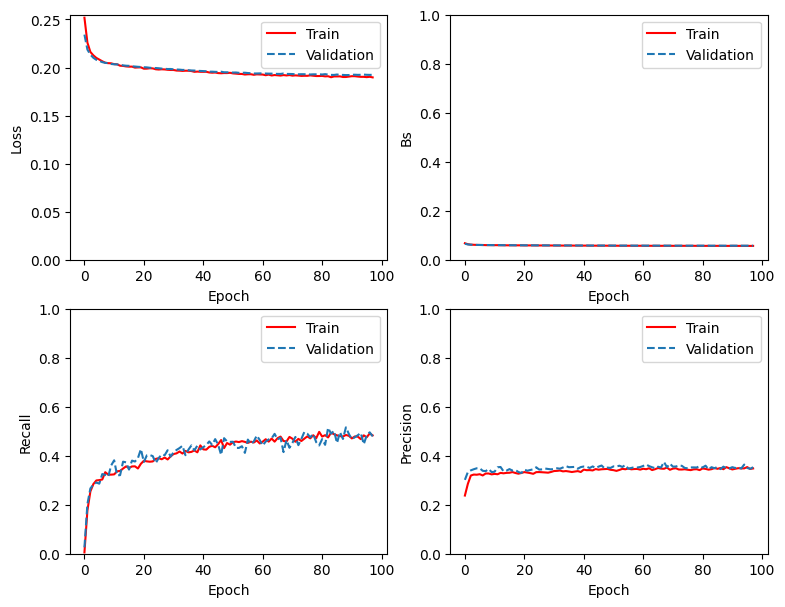

In [32]:
plot_metrics(model_history)

### Performance on testing data

In [33]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.08695014


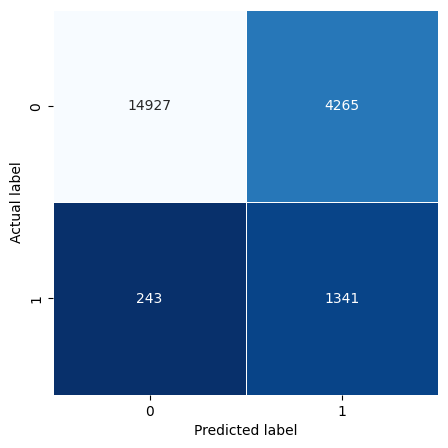

In [34]:
y_hat_val, auc_val, bs_val = class_prediction(x_val, y_val)
classification_threshold_val = cutoff_youdens_j(*roc_curve(y_val, y_hat_val))
print(classification_threshold_val)
plot_cm(y_val, y_hat_val, classification_threshold=classification_threshold_val)

In [35]:
average_precision_score(y_val, y_hat_val)

0.3526169569573101

633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


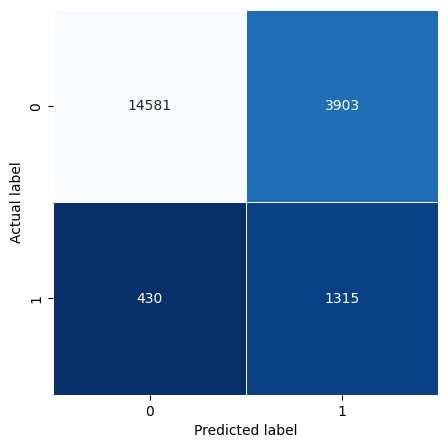

In [36]:
y_hat_test, auc_test, bs_test = class_prediction(x_test, y_test)
classification_threshold = cutoff_youdens_j(*roc_curve(y_test, y_hat_test))
plot_cm(y_test, y_hat_test, classification_threshold=classification_threshold_val)

In [37]:
average_precision_score(y_test, y_hat_test)

0.33014743908212274

In [39]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

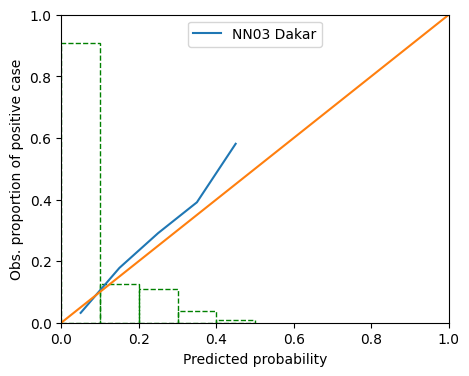

In [40]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_hat_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NN0{lead_time} Dakar")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [41]:
#model.save(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-t{lead_time}.keras')

In [42]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

2597/2597 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


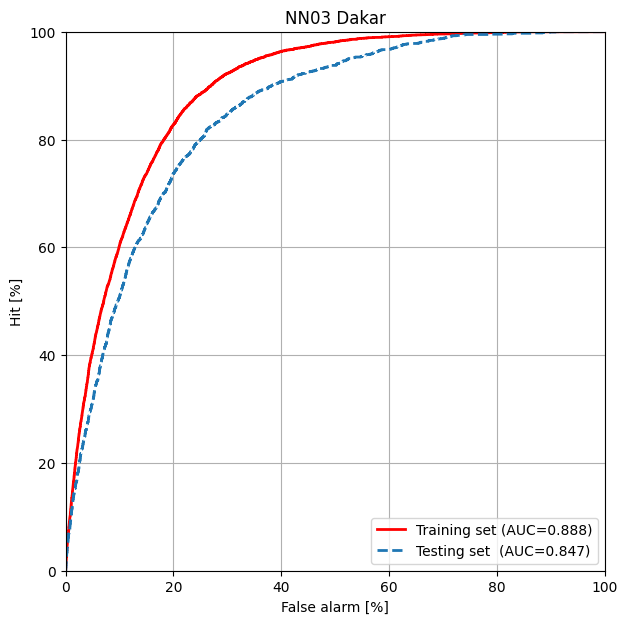

In [43]:
y_hat_train, auc_train, bs_train = class_prediction(x_train, y_train)
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train, y_hat_train, color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.title(f"NN0{lead_time} Dakar")
plt.legend(loc='lower right');